In [2]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Usama\Downloads\internship_applications_dataset.csv")
df.head()

,application_id,name,email,ip_address,submission_time,university,cgpa,skills_count,device_type
0,1,Sara Ahmed,sara.ahmed13@gmail.com,192.168.1.191,2025-01-02 05:01:37,LUMS,2.83,3,Tablet
1,2,Fatima Zahra,fatima.zahra45@gmail.com,192.168.1.153,2025-01-02 15:43:24,NUST,2.54,5,Laptop
2,3,Fatima Zahra,fatima.zahra309@gmail.com,192.168.1.8,2025-01-03 01:52:07,LUMS,3.57,10,Mobile
3,4,Ayesha Noor,ayesha.noor230@gmail.com,192.168.1.152,2025-01-02 05:15:26,NUST,3.64,4,Tablet
4,5,Bilal Tariq,bilal.tariq175@gmail.com,192.168.1.73,2025-01-01 20:19:18,LUMS,3.94,7,Laptop


In [17]:
# Duplicate email count
df['email_count'] = df.groupby('email')['email'].transform('count')

# Sort by IP and submission_time
df = df.sort_values(['ip_address','submission_time'])
df['time_diff_sec'] = df.groupby('ip_address')['submission_time'].diff().dt.total_seconds().fillna(0)

# Encode categorical features
from sklearn.preprocessing import LabelEncoder
le_device = LabelEncoder()
le_uni = LabelEncoder()
df['device_type_enc'] = le_device.fit_transform(df['device_type'])
df['university_enc'] = le_uni.fit_transform(df['university'])

# Features for ML
features = df[['cgpa','skills_count','device_type_enc','university_enc','email_count','time_diff_sec']]

In [18]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_iso'] = iso.fit_predict(features)
df['anomaly_iso'] = df['anomaly_iso'].map({1:0, -1:1})  # 1 = anomaly

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import numpy as np

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=5, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)

distances = np.linalg.norm(X_scaled - kmeans.cluster_centers_[df['cluster']], axis=1)
threshold = np.percentile(distances, 95)
df['anomaly_kmeans'] = (distances > threshold).astype(int)

In [20]:
df['suspicious'] = ((df['anomaly_iso']==1) | (df['anomaly_kmeans']==1)).astype(int)

# Define suspicious_apps
suspicious_apps = df[df['suspicious']==1]

In [21]:
for idx, row in suspicious_apps.iterrows():
    print(f"Alert! Suspicious application detected: ID={row['application_id']}, Email={row['email']}, IP={row['ip_address']}")

Alert! Suspicious application detected: ID=230, Email=ahmed.noor23@gmail.com, IP=192.168.1.107
Alert! Suspicious application detected: ID=153, Email=hassan.raza328@gmail.com, IP=192.168.1.110
Alert! Suspicious application detected: ID=193, Email=ayesha.noor414@gmail.com, IP=192.168.1.111
Alert! Suspicious application detected: ID=389, Email=ahmed.noor172@gmail.com, IP=192.168.1.112
Alert! Suspicious application detected: ID=326, Email=fatima.zahra468@gmail.com, IP=192.168.1.122
Alert! Suspicious application detected: ID=294, Email=maria.khan412@gmail.com, IP=192.168.1.123
Alert! Suspicious application detected: ID=234, Email=ali.khan329@gmail.com, IP=192.168.1.125
Alert! Suspicious application detected: ID=36, Email=usman.ali209@gmail.com, IP=192.168.1.126
Alert! Suspicious application detected: ID=59, Email=maria.khan329@gmail.com, IP=192.168.1.132
Alert! Suspicious application detected: ID=113, Email=ahmed.noor38@gmail.com, IP=192.168.1.149
Alert! Suspicious application detected: ID=

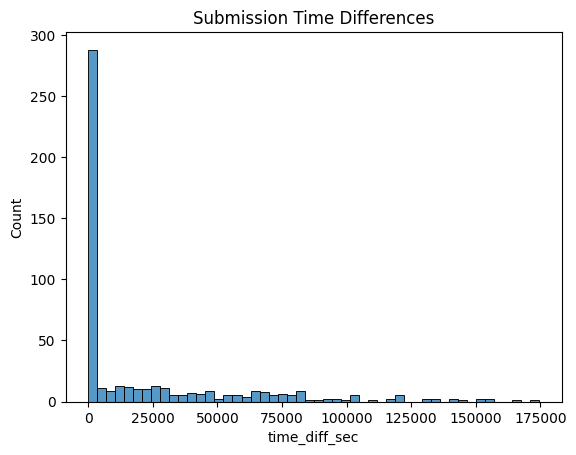

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['time_diff_sec'], bins=50)
plt.title("Submission Time Differences")
plt.show()

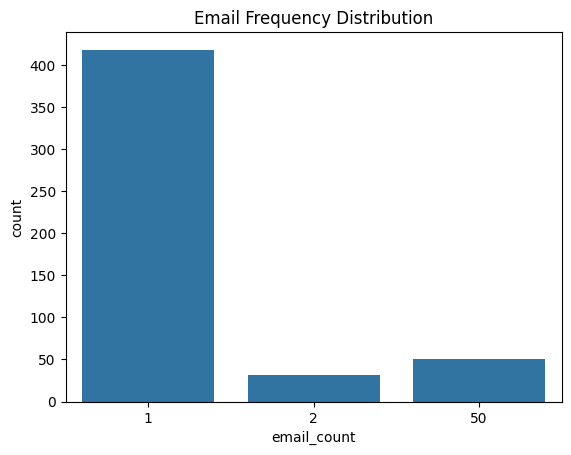

In [23]:
sns.countplot(x='email_count', data=df)
plt.title("Email Frequency Distribution")
plt.show()

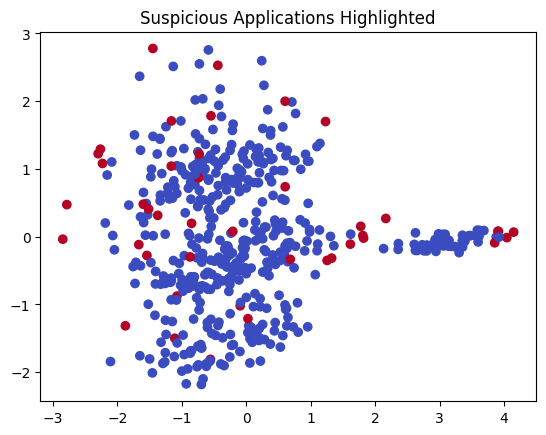

In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.scatter(X_pca[:,0], X_pca[:,1], c=df['suspicious'], cmap='coolwarm')
plt.title("Suspicious Applications Highlighted")
plt.show()